In [3]:
%load_ext autoreload
%autoreload 2

import mteb
from itertools import product
from utils.dataloaders.text_dataloader import load_dataset
import numpy as np
import tqdm
import matplotlib.pyplot as plt

from utils.model_definitions.vision_automodel_wrapper import VisionLayerwiseAutoModelWrapper, VisionModelSpecifications
from utils.dataloaders.vision_dataloader import prepare_datasets, prepare_dataloader, validation_imagenet_transform, simclr_imagenet_transform
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score
)
from utils.metrics.metric_functions import compute_entropy
import torch
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from transformers.utils import logging
logging.set_verbosity_error()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vision Task

In [3]:
model_specs = VisionModelSpecifications(
    model_family="vit", 
    model_size="base", 
    revision="main")
model = VisionLayerwiseAutoModelWrapper(model_specs, device_map="auto")

In [4]:
image_transform = validation_imagenet_transform()

validation_imagenet_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/train",
    number_of_samples=-1
)

validation_dataloader = prepare_dataloader(validation_imagenet_dataset, batch_size=32, num_workers=16, shuffle=True)


## Test Class Subsampling

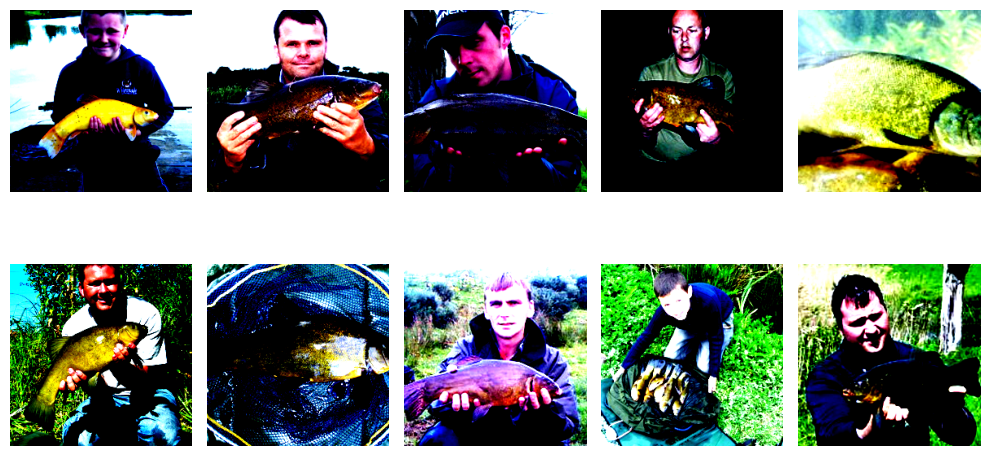

In [5]:
import matplotlib.pyplot as plt
desired_classes = [0]

# filter the dataset to only include the desired classes
indices = [i for i, x in enumerate(validation_imagenet_dataset.targets) if x in desired_classes]

# create a new dataset with the filtered indices
filtered_dataset = torch.utils.data.Subset(validation_imagenet_dataset, indices)

filtered_dataloader = prepare_dataloader(filtered_dataset, batch_size=32, num_workers=16, shuffle=True)

for batch in filtered_dataloader:
    # Get 4 random indices from the batch
    batch_size = len(batch[1])
    random_indices = np.random.choice(batch_size, 10, replace=False)
    images = [batch[1][i] for i in random_indices]
    break

# Create a 5x2 subplot
fig, axes = plt.subplots(2, 5, figsize=(10, 6))

for idx, image in enumerate(images):
    # Convert to numpy and reshape
    img = image.cpu().numpy().reshape(3, 224, 224)
    img = np.transpose(img, (1, 2, 0))
    
    # Plot in the corresponding subplot
    row = idx // 5
    col = idx % 5
    axes[row, col].imshow(img)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Main Experiments

In [5]:
import os
import pickle

def save_results(results, seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def check_if_results_exist(seed, num_classes):
    path = f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/"
    path += f"CLASSES_{num_classes}/"
    path += f"SEED_{seed}.pkl"

    return os.path.exists(path)


In [7]:
def calculate_entropy(encodings):
    encodings = encodings / np.linalg.norm(encodings, axis=1, keepdims=True)
    encodings = torch.tensor(encodings)
    if len(encodings.shape) == 2:
        encodings = encodings.unsqueeze(0)

    entropy = compute_entropy(encodings)

    if len(entropy['maxEntropy']) == 1:
        return entropy['maxEntropy'][0]
    else:
        return entropy['maxEntropy']

def calculate_average_layerwise_prompt_entropies(sample_hidden_states):
    layerwise_entropies = []
    for sample in tqdm.tqdm(sample_hidden_states, disable=True):
        entropies = calculate_entropy(sample)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)

    return layerwise_entropies.mean(axis=0)

def calculate_layerwise_dataset_entropies(layerwise_encodings):
    layerwise_entropies = []
    for layer in tqdm.tqdm(layerwise_encodings, disable=True):
        entropies = calculate_entropy(layer)
        layerwise_entropies.append(entropies)

    layerwise_entropies = np.array(layerwise_entropies)
    return layerwise_entropies

In [8]:
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler

def process_layer(x_train, x_test, y_train, y_test):
    normalized_X_train = StandardScaler().fit_transform(x_train) 
    normalized_X_test = StandardScaler().fit_transform(x_test)

    clf = LogisticRegression(
        n_jobs=2,
        max_iter=250
    )
    clf.fit(normalized_X_train, y_train)
    y_pred = clf.predict(normalized_X_test)
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, average='macro'),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro')
    }

def filter_dataset(dataset, classes):

    # limit to 1000 samples per class
    subsampled_indices = []
    for class_idx in classes:
        class_indices = [i for i, x in enumerate(dataset.targets) if x == class_idx]

        if len(class_indices) > 200:
            subsampled_indices.extend(np.random.choice(class_indices, size=500, replace=False))
        else:
            subsampled_indices.extend(class_indices)

    return torch.utils.data.Subset(dataset, subsampled_indices)

In [10]:
# adapted from https://github.com/embeddings-benchmark/mteb/blob/762f729b70cdad2e9137a68af4b2693ca96dd3b7/mteb/abstasks/AbsTaskClassification.py#L132

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

NUM_CLASSES = 32
NUM_EXPERIMENTS = 50
SEED_START = 0

RESULTS = []

image_transform = validation_imagenet_transform()

full_imagenet_train_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/train",
    number_of_samples=-1
)
full_imagenet_val_dataset = prepare_datasets(
    dataset="imagenet",
    transform=image_transform,
    train_data_path="/home/AD/ofsk222/Research/exploration/information_plane/experiments/datasets/imagenet/ILSVRC/Data/CLS-LOC/val_sorted",
    number_of_samples=-1
)

for i in range(NUM_EXPERIMENTS):
    torch.manual_seed(SEED_START + i)
    np.random.seed(SEED_START + i)

    if check_if_results_exist(SEED_START + i, NUM_CLASSES):
        print(f"Results for seed {SEED_START + i} and {NUM_CLASSES} classes already exist")
        continue

    chosen_classes = np.random.choice(np.unique(full_imagenet_train_dataset.targets), size=NUM_CLASSES, replace=False)
    train_dataset = filter_dataset(full_imagenet_train_dataset, chosen_classes)
    test_dataset = filter_dataset(full_imagenet_val_dataset, chosen_classes)

    kwargs = {
        "verbose": True
    }
    encoded_train, raw_hidden_states_train, layerwise_encodings_train, y_train = model.encode(train_dataset, return_raw_hidden_states=True, **kwargs)
    encoded_test, raw_hidden_states_test, layerwise_encodings_test, y_test = model.encode(test_dataset, return_raw_hidden_states=True, **kwargs)

    # Process all layers in parallel
    results = Parallel(n_jobs=-1)(
        delayed(process_layer)(layerwise_encodings_train[idx], layerwise_encodings_test[idx], y_train, y_test) 
        for idx in range(len(layerwise_encodings_train))
    )
    layerwise_accuracies = [r['accuracy'] for r in results]
    layerwise_f1_scores = [r['f1'] for r in results]
    layerwise_precisions = [r['precision'] for r in results]
    layerwise_recalls = [r['recall'] for r in results]


    experiment_results = {
        "accuracy": layerwise_accuracies,
        "f1_score": layerwise_f1_scores,
        "precision": layerwise_precisions,
        "recall": layerwise_recalls,
        "seed": SEED_START + i,
        "num_classes": NUM_CLASSES,
        "num_samples": len(y_test),
        "classes": chosen_classes,
        'prompt_entropy': calculate_average_layerwise_prompt_entropies(raw_hidden_states_test),
        'dataset_entropy': calculate_layerwise_dataset_entropies(layerwise_encodings_test)
    }

    RESULTS.append(experiment_results)
    save_results(experiment_results, SEED_START + i, NUM_CLASSES)

Results for seed 0 and 32 classes already exist


100%|██████████| 7/7 [00:22<00:00,  3.22s/it]
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for

KeyboardInterrupt: 

In [21]:
print(RESULTS[0]['f1_score'])

[0.0964247326305739, 0.48874243716606347, 0.6049850481510289, 0.6660892522032154, 0.7291639568389234, 0.7717784291856525, 0.8157505565383063, 0.8576096467482481, 0.8935924342891816, 0.9210955395635496, 0.9420366674775735, 0.9538426840315367, 0.9525320906354965]


In [19]:
# plot the prompt entropy
plt.figure(figsize=(15, 5))
plt.plot(RESULTS[0]['prompt_entropy'])
plt.show()

NameError: name 'RESULTS' is not defined

<Figure size 1500x500 with 0 Axes>

## Load Results

In [20]:
CLASSNUM_LIST = [32]

model_specs = VisionModelSpecifications(
    model_family="vit", 
    model_size="base", 
    revision="main")


CLASSNUM_TO_RESULTS = {}
for classnum in CLASSNUM_LIST:
    classnum_results = []
    for i in range(100):
        if check_if_results_exist(i, classnum):
            with open(f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/CLASSES_{classnum}/SEED_{i}.pkl", "rb") as f:
                classnum_results.append(pickle.load(f))
    CLASSNUM_TO_RESULTS[classnum] = classnum_results


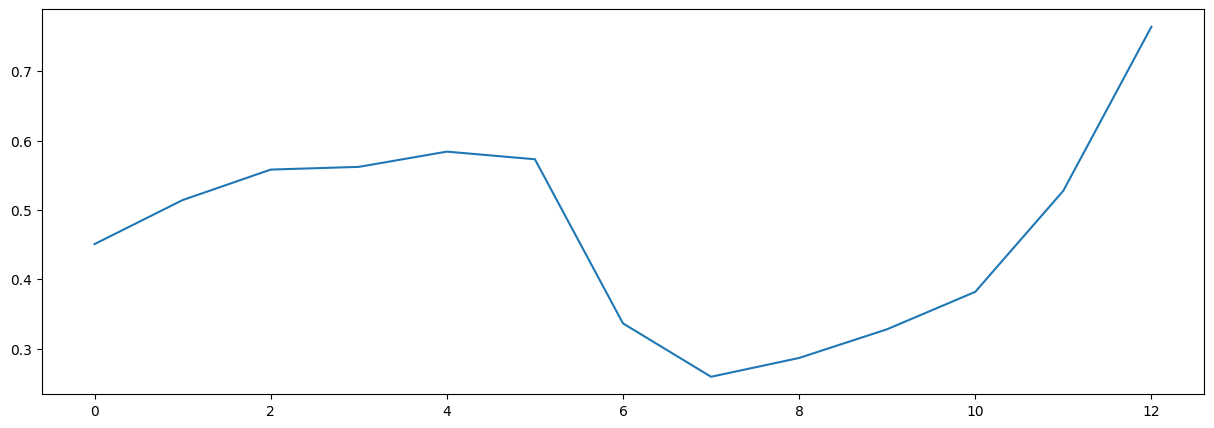

In [22]:
# Plot the results
plt.figure(figsize=(15, 5))
plt.plot(CLASSNUM_TO_RESULTS[32][0]['dataset_entropy'])
plt.show()

## Compare Text and Vision

In [12]:
CLASSNUM_LIST = [32]

model_specs = VisionModelSpecifications(
    model_family="vit", 
    model_size="base", 
    revision="main")


VISION_CLASSNUM_TO_RESULTS = {}
for classnum in CLASSNUM_LIST:
    classnum_results = []
    for i in range(100):
        if check_if_results_exist(i, classnum):
            with open(f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/CLASSES_{classnum}/SEED_{i}.pkl", "rb") as f:
                classnum_results.append(pickle.load(f))
    VISION_CLASSNUM_TO_RESULTS[classnum] = classnum_results

In [26]:
CLASSNUM_LIST = [8, 16, 32]

model_specs = TextModelSpecifications(
    model_family="Pythia", 
    model_size="410m", 
    revision="main")

TEXT_CLASSNUM_TO_RESULTS = {}
for classnum in CLASSNUM_LIST:
    classnum_results = []
    for i in range(100):
        if check_if_results_exist(i, classnum):
            with open(f"results/{model_specs.model_family}/{model_specs.model_size}/{model_specs.revision}/classification_subsets/CLASSES_{classnum}/SEED_{i}.pkl", "rb") as f:
                classnum_results.append(pickle.load(f))
    TEXT_CLASSNUM_TO_RESULTS[classnum] = classnum_results

In [27]:
print(len(TEXT_CLASSNUM_TO_RESULTS[32]))

100


In [39]:
text_f1_scores

array([[0.88, 0.85, 0.87, ..., 0.88, 0.88, 0.88],
       [0.87, 0.87, 0.88, ..., 0.89, 0.89, 0.88],
       [0.88, 0.88, 0.88, ..., 0.88, 0.89, 0.89],
       ...,
       [0.87, 0.86, 0.89, ..., 0.91, 0.91, 0.9 ],
       [0.83, 0.84, 0.86, ..., 0.89, 0.88, 0.88],
       [0.85, 0.81, 0.86, ..., 0.86, 0.86, 0.85]])

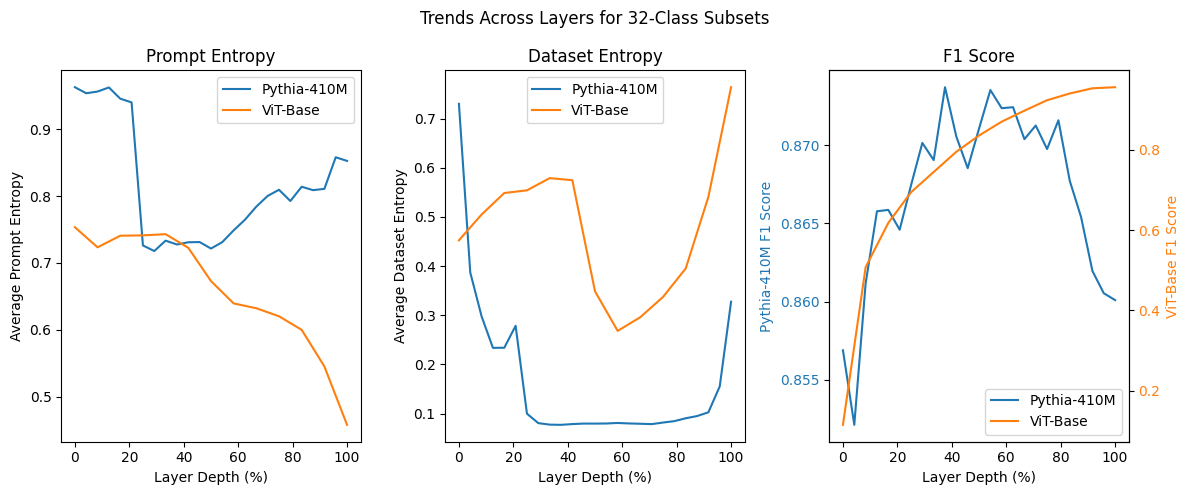

In [42]:
# plot the average prompt and dataset entropies across layers

text_prompt_entropies = np.array([result['prompt_entropy'] for result in TEXT_CLASSNUM_TO_RESULTS[32]])
vision_prompt_entropies = np.array([result['prompt_entropy'] for result in VISION_CLASSNUM_TO_RESULTS[32]])

text_f1_scores = np.array([result['f1_score'] for result in TEXT_CLASSNUM_TO_RESULTS[32]])
vision_f1_scores = np.array([result['f1_score'] for result in VISION_CLASSNUM_TO_RESULTS[32]])

text_dataset_entropies = np.array([result['dataset_entropy'] for result in TEXT_CLASSNUM_TO_RESULTS[32]])
vision_dataset_entropies = np.array([result['dataset_entropy'] for result in VISION_CLASSNUM_TO_RESULTS[32]])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

text_layers = np.linspace(0, 100, len(text_prompt_entropies.mean(axis=0)))
vision_layers = np.linspace(0, 100, len(vision_prompt_entropies.mean(axis=0)))

# Plot prompt entropies
ax1.plot(text_layers, text_prompt_entropies.mean(axis=0), label='Pythia-410M')
ax1.plot(vision_layers, vision_prompt_entropies.mean(axis=0), label='ViT-Base')
ax1.set_xlabel('Layer Depth (%)')
ax1.set_ylabel('Average Prompt Entropy')
ax1.set_title('Prompt Entropy')
ax1.legend()

# Plot dataset entropies
ax2.plot(text_layers, text_dataset_entropies.mean(axis=0), label='Pythia-410M')
ax2.plot(vision_layers, vision_dataset_entropies.mean(axis=0), label='ViT-Base')
ax2.set_xlabel('Layer Depth (%)')
ax2.set_ylabel('Average Dataset Entropy')
ax2.set_title('Dataset Entropy')
ax2.legend()

# plot average f1 scores
# Create twin axis
ax3_twin = ax3.twinx()

# Plot text F1 scores on left axis
ax3.plot(text_layers, text_f1_scores.mean(axis=0), label='Pythia-410M', color='C0')
ax3.set_ylabel('Pythia-410M F1 Score', color='C0')
ax3.tick_params(axis='y', labelcolor='C0')

# Plot vision F1 scores on right axis  
ax3_twin.plot(vision_layers, vision_f1_scores.mean(axis=0), label='ViT-Base', color='C1')
ax3_twin.set_ylabel('ViT-Base F1 Score', color='C1')
ax3_twin.tick_params(axis='y', labelcolor='C1')

ax3.set_xlabel('Layer Depth (%)')
ax3.set_title('F1 Score')

# Add legend
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2)

plt.suptitle('Trends Across Layers for 32-Class Subsets')
plt.tight_layout()
plt.show()
